# Graphing the Data


## Imports and helper functions

In [1]:
# Processing data
import pandas as pd
import numpy as np

# For Plotly
import plotly.express as px
import plotly.tools as tools

#For converting film budget currencies
from currency_converter import CurrencyConverter, ECB_URL

# Jupyter magic for helper code
%run helpers.ipynb

### Read in joined dataframes

In [2]:
oscar_with_imdb, imdb_non_oscar = read_data('oscar_with_imdb.csv', 'imdb_non_oscar.csv')

To plot all films at once regardless of nomination status, we use the columns as series to concatenate them into a data frame. This allows the budget and box office variables to be used as combined axes for Plotly Express.

In [3]:
oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row == True else 'Nominated')
imdb_non_oscar['Status'] = 'No nomination'

budget_nom = oscar_with_imdb['budget']
gross_nom = oscar_with_imdb['gross_worldwide']

budget_imdb = imdb_non_oscar['budget']
gross_imdb = imdb_non_oscar['gross_worldwide']

oscar_noms = pd.concat([budget_nom, gross_nom, oscar_with_imdb['Status']], axis=1)
non_noms = pd.concat([budget_imdb, gross_imdb, imdb_non_oscar['Status']], axis=1)

combined_films = pd.concat([oscar_noms, non_noms], axis=0)
combined_films.dropna(how='any', inplace=True)

## Setting up data for scatter plot (Budget vs Box Office)

We want to categorize films by their academy award status or if they were not nominated. We begin by adding False entries to the `Winner` field in the joined data frame for Academy Award films, and then dropping any NA values in both joined data frames.

### Create `Status` field

In [4]:
temp_oscar_with_imdb = oscar_with_imdb.dropna(subset=['budget', 'gross_worldwide'])
temp_imdb_non_oscar = imdb_non_oscar.dropna(subset=['budget', 'gross_worldwide'])

# Nominess are marked as NaN so we replace with False
temp_oscar_with_imdb['Winner'] = oscar_with_imdb['Winner'].fillna(False)

In [5]:
temp_oscar_with_imdb['Status'] = temp_oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row else 'Nominated')

winners = temp_oscar_with_imdb[temp_oscar_with_imdb['Status'] == 'Winner']
nominees = temp_oscar_with_imdb[temp_oscar_with_imdb['Status'] == 'Nominated']
non_nom = temp_imdb_non_oscar

all_films = [winners, nominees, non_nom]
to_graph = [None, None, None]
film_groups = ['Won', 'Nominated', 'Not Nominated']

### Round budget and box and budget

#### Initialize currency converter to pass into lambda
The included file `eurofxref-hist.csv` uses historical rates from the European Central Bank to initialize the converter. When the converter is passed into the the lambda function, it will base all exchange rates on this data.

In [6]:
currency_conv = CurrencyConverter('eurofxref-hist.csv', fallback_on_missing_rate=True, fallback_on_wrong_date=True)

For each data frame, convert the currencies and add a new column

In [7]:
for i, df in enumerate(all_films):
    for j, row in df.iterrows():
        release_date = row['release_date']
    df['normalized_budget'] = df['budget'].apply(lambda x: normalize_budget(x, release_date, currency_conv))
    to_graph[i] = df

In [8]:
for i, df in enumerate(to_graph):
    df = df[df['normalized_budget'] != 0]
    to_graph[i] = df

In [15]:
df1, df2, df3 = to_graph
all_films_scatter = pd.concat([df1, df2, df3], ignore_index=True)

The `CurrencyConverter` library allowed for quick parsing, but had some failed lookups for currency. We have to drop films with currencies that did not properly convert or hard code the conversion rate. 

In [16]:
for df in to_graph:
    df['rounded_budget'] = df['normalized_budget'].copy().apply(round_value)
    df['rounded_gross'] = df['gross_worldwide'].apply(round_value)
    
    # Drop NA and zero values
    df = df.dropna(subset=['rounded_budget', 'rounded_gross'])
    df = df[(df['rounded_budget'] > 0) & (df['rounded_gross'] > 0)]

## Creating the scatter plot for film budget and box office

### Iterate through rows and add points to scatter plot
We only want to display a film once despite how many nominations or awards it received, so we remove duplicates in the dataframe. We then add the rounded budgets and box office earnings to a scatter plot along with tooltips to display the film's IMDb votes, rating, and title along with the budget and earnings.

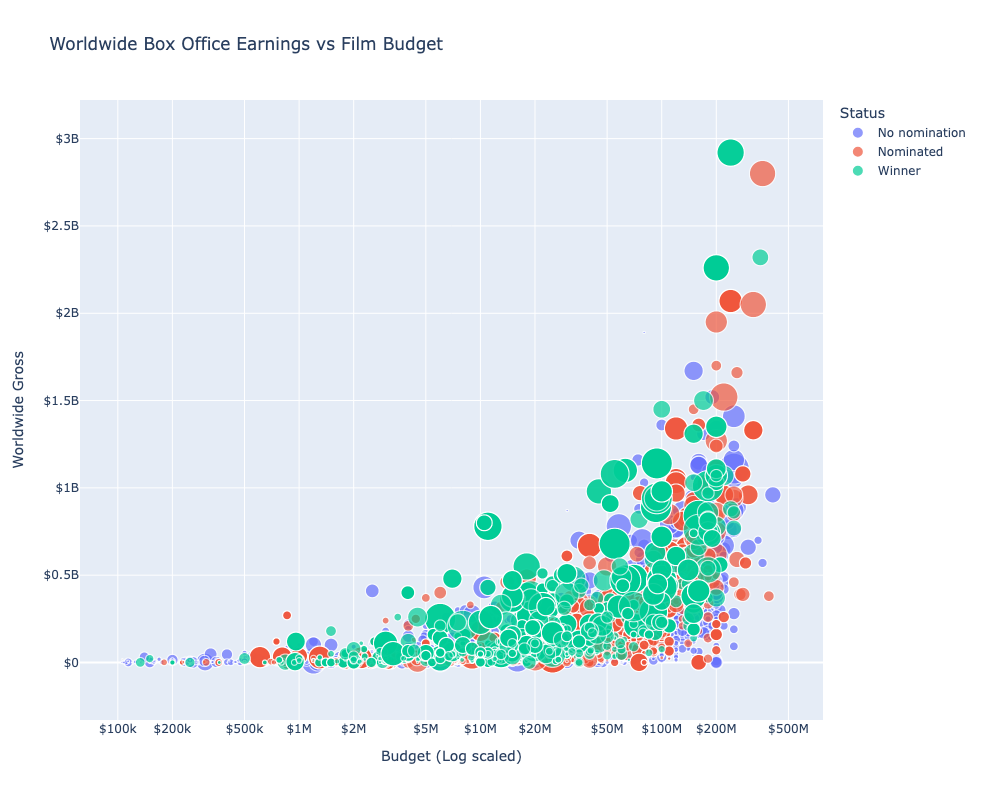

In [41]:
df1 = to_graph[0]
df2 = to_graph[1]
df3 = to_graph[2]
df3 = df3.rename(columns={'title': 'Film'})

all_films_scatter = pd.concat([df1, df2, df3], ignore_index=True)

# remove duplicate films between Oscar nominees/winners (every film should appear only once)
winner_ids = all_films_scatter.loc[all_films_scatter['Status'] == 'Winner', 'FilmId']
all_films_scatter = all_films_scatter[
    (all_films_scatter['Status'] != 'Nominated') |
    (~all_films_scatter['FilmId'].isin(winner_ids))
]

fig = px.scatter(
    all_films_scatter,
    x='rounded_budget',
    y='rounded_gross',
    size='votes',
    size_max=40,
    color='Status',
    title='Worldwide Box Office Earnings vs Film Budget',
    custom_data=['votes', 'rating', 'Film'],
    category_orders={
        'Status': ['No nomination', 'Nominated', 'Winner']
    },
    hover_data={
        'Status': False,
        'votes': ':,',
        'rating': True,
        'Film': True if 'Film' in all_films_scatter.columns else False
    },
    labels={
        'rounded_budget': 'Budget',
        'rounded_gross': 'Gross',
        'votes': 'User Votes',
        'rating': 'IMDb Rating'
    }
)

fig.update_layout(
    xaxis_type='log',
    xaxis_title='Budget (Log scaled)',
    yaxis_title='Worldwide Gross',
    xaxis_tickformat='$~s',
    yaxis_tickprefix='$',
    height=800
)

fig.update_traces(
    hovertemplate=
        "Budget=$%{x:.2~s}<br>"
        "Gross=$%{y:.2~s}<br>"
        "User Votes=%{customdata[0]:,}<br>"
        "IMDb Rating=%{customdata[1]}<br>"
        "Film=%{customdata[2]}"
        "<extra></extra>"
)

fig.show(config={'displayModeBar': False})